# Project 74: Canopy Coverage Forecasting

**Objective:** Predict Melbourne's tree canopy coverage for 2026 and 2030 using time-series analysis

**Methods:**
1. Linear Regression - simple trend-based forecast
2. Statistical metrics - calculate confidence intervals

**Policy Question:** At current growth rate, will Melbourne meet its 40% canopy target by 2040?

## Step 1: Importing Libraries and Loading Summary Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Setting visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Step 2: Creating Historical Data for Forecasting

In [2]:
# Historical canopy data from our analysis
canopy_data = pd.DataFrame({
    'Year': [2008, 2011, 2016, 2021],
    'Canopy_Ha': [429.85, 410.20, 433.24, 442.36]
})

print("Historical Canopy Coverage:")
display(canopy_data)

Historical Canopy Coverage:


,Year,Canopy_Ha
0,2008,429.85
1,2011,410.20
2,2016,433.24
3,2021,442.36


## Step 3: Build Linear Regression Model

Linear regression finds the best-fit straight line through our data points, then extends that line into the future to make predictions.

In [3]:
# Prepare data for linear regression
X = canopy_data['Year'].values.reshape(-1, 1)  # Reshape to 2D array for sklearn
y = canopy_data['Canopy_Ha'].values

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Model parameters
slope = model.coef_[0]
intercept = model.intercept_
r_squared = r2_score(y, model.predict(X))

print("Linear Regression Model:")
print(f"  Slope: {slope:.4f} hectares/year")
print(f"  Intercept: {intercept:.2f}")
print(f"  R² Score: {r_squared:.4f}")

Linear Regression Model:
  Slope: 1.5643 hectares/year
  Intercept: -2721.56
  R² Score: 0.4355


## Step 4: Making Predictions for 2026 and 2030

In [4]:
# Predict future canopy coverage
future_years = np.array([2026, 2030]).reshape(-1, 1)
predictions = model.predict(future_years)

print("Canopy Coverage Forecasts:")
print(f"  2026: {predictions[0]:.2f} hectares")
print(f"  2030: {predictions[1]:.2f} hectares")

Canopy Coverage Forecasts:
  2026: 447.68 hectares
  2030: 453.94 hectares


## Step 5: Visualizing Historical Data and Forecast

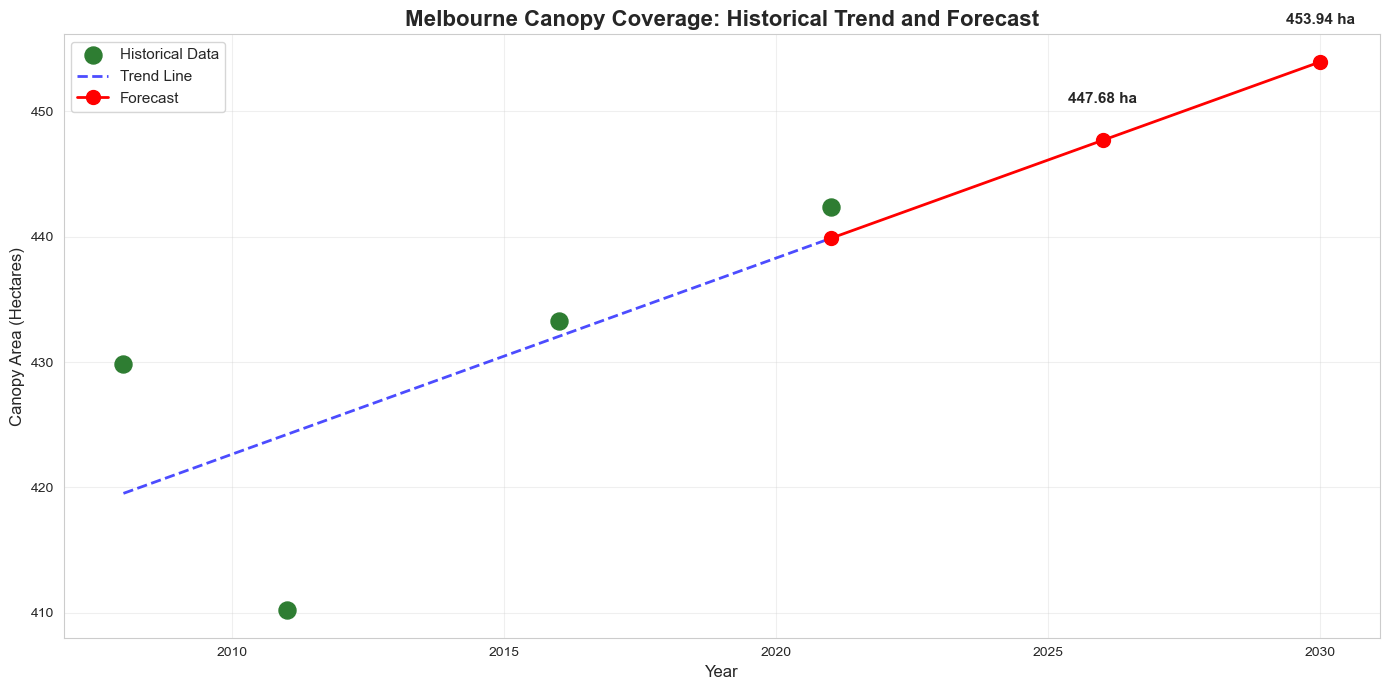

Forecast visualization saved


In [5]:
# Create forecast visualization
plt.figure(figsize=(14, 7))

# Plot historical data
plt.scatter(canopy_data['Year'], canopy_data['Canopy_Ha'], 
            s=150, color='#2E7D32', label='Historical Data', zorder=3)

# Plot regression line through historical period
years_range = np.arange(2008, 2022).reshape(-1, 1)
plt.plot(years_range, model.predict(years_range), 
         'b--', linewidth=2, label='Trend Line', alpha=0.7)

# Plot forecast
forecast_years = np.array([2021, 2026, 2030]).reshape(-1, 1)
forecast_values = model.predict(forecast_years)
plt.plot(forecast_years, forecast_values, 
         'r-', linewidth=2, label='Forecast', marker='o', markersize=10)

# Add labels for predictions
plt.text(2026, predictions[0] + 3, f"{predictions[0]:.2f} ha", 
         ha='center', fontsize=11, fontweight='bold')
plt.text(2030, predictions[1] + 3, f"{predictions[1]:.2f} ha", 
         ha='center', fontsize=11, fontweight='bold')

plt.title('Melbourne Canopy Coverage: Historical Trend and Forecast', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Canopy Area (Hectares)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('../outputs/canopy_forecast_2026_2030.png', dpi=300, bbox_inches='tight')
plt.show()

print("Forecast visualization saved")

## Step 6: Policy Analysis - 40% Target Assessment

Calculate if current growth rate will achieve Melbourne's 2040 target.

In [6]:
# Predict 2040
year_2040 = np.array([[2040]])
predicted_2040 = model.predict(year_2040)[0]

print("Policy Target Analysis:")
print("="*70)
print(f"Current canopy (2021): {canopy_data.iloc[-1]['Canopy_Ha']:.2f} hectares")
print(f"Predicted canopy (2040): {predicted_2040:.2f} hectares")
print(f"Annual growth rate: {slope:.2f} hectares/year")
print(f"\nNote: Target is 40% canopy coverage (specific hectare target depends on total city area)")

Policy Target Analysis:
Current canopy (2021): 442.36 hectares
Predicted canopy (2040): 469.58 hectares
Annual growth rate: 1.56 hectares/year

Note: Target is 40% canopy coverage (specific hectare target depends on total city area)
